 # Section 1 :
 ## Load the Data

In [ ]:
import pandas as pd

Load the dataset directly from GitHub

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/CunyLaguardiaDataAnalytics/datasets/master/Salaries.csv")

Quick look at the first 5 rows

In [ ]:
df.head()

,Unnamed: 0,rank,discipline,yrs.since.phd,yrs.service,sex,salary
0,1,Prof,B,19,18,Male,139750
1,2,Prof,B,20,16,Male,173200
2,3,AsstProf,B,4,3,Male,79750
3,4,Prof,B,45,39,Male,115000
4,5,Prof,B,40,41,Male,141500


# Section 2:
# Data Exploration

Check the shape (rows, columns) and column names

In [ ]:
print(df.shape)

(397, 7)


In [ ]:
print(df.columns)

Index(['Unnamed: 0', 'rank', 'discipline', 'yrs.since.phd', 'yrs.service',
       'sex', 'salary'],
      dtype='object')


Get data types and check for missing values

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397 entries, 0 to 396
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Unnamed: 0     397 non-null    int64 
 1   rank           397 non-null    object
 2   discipline     397 non-null    object
 3   yrs.since.phd  397 non-null    int64 
 4   yrs.service    397 non-null    int64 
 5   sex            397 non-null    object
 6   salary         397 non-null    int64 
dtypes: int64(4), object(3)
memory usage: 21.8+ KB


Overall summary statistics for numeric columns

In [ ]:
df.describe()

,Unnamed: 0,yrs.since.phd,yrs.service,salary
count,397.000000,397.000000,397.000000,397.000000
mean,199.000000,22.314861,17.614610,113706.458438
std,114.748275,12.887003,13.006024,30289.038695
min,1.000000,1.000000,0.000000,57800.000000
25%,100.000000,12.000000,7.000000,91000.000000
50%,199.000000,21.000000,16.000000,107300.000000
75%,298.000000,32.000000,27.000000,134185.000000
max,397.000000,56.000000,60.000000,231545.000000


Mean and Median salary for ALL rows

In [ ]:
mean_salary = df['salary'].mean()
median_salary = df['salary'].median()
print(f"Mean salary: {mean_salary}")
print(f"Median salary: {median_salary}")

Mean salary: 113706.45843828715
Median salary: 107300.0


Median salary broken down by gender (sex)

In [ ]:
median_salary_sex = df.groupby('sex')['salary'].median()
print(median_salary_sex)

sex
Female    103750.0
Male      108043.0
Name: salary, dtype: float64


Median salary broken down by rank/title

In [ ]:
median_salary_rank = df.groupby('rank')['salary'].median()
print(median_salary_rank)

rank
AssocProf     95626.5
AsstProf      79800.0
Prof         123321.5
Name: salary, dtype: float64


Median salary broken down by BOTH sex and rank

In [ ]:
median_salary_sex_rank = df.groupby(['sex', 'rank'])['salary'].median()
print(median_salary_sex_rank)

sex     rank     
Female  AssocProf     90556.5
        AsstProf      77000.0
        Prof         120257.5
Male    AssocProf     95626.5
        AsstProf      80182.0
        Prof         123996.0
Name: salary, dtype: float64


# Section : 3
# Data Wrangling

Rename columns to lowercase, no spaces (adjust names based on your actual columns)

Subset : keep only the columns we actually need for this analysis

In [ ]:
df_subset = df[['rank', 'sex', 'salary']]
print(df_subset)

         rank   sex  salary
0        Prof  Male  139750
1        Prof  Male  173200
2    AsstProf  Male   79750
3        Prof  Male  115000
4        Prof  Male  141500
..        ...   ...     ...
392      Prof  Male  103106
393      Prof  Male  150564
394      Prof  Male  101738
395      Prof  Male   95329
396  AsstProf  Male   81035

[397 rows x 3 columns]


Check for missing data in each column

In [ ]:
print(df.isnull().sum())

Unnamed: 0       0
rank             0
discipline       0
yrs.since.phd    0
yrs.service      0
sex              0
salary           0
dtype: int64


In [ ]:
df.isnull()


,Unnamed: 0,rank,discipline,yrs.since.phd,yrs.service,sex,salary
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
392,False,False,False,False,False,False,False
393,False,False,False,False,False,False,False
394,False,False,False,False,False,False,False
395,False,False,False,False,False,False,False


In [ ]:
df.dropna(axis=0,inplace=True)

In [ ]:
df.rename(columns={'Unnamed: 0':'Id'},inplace=True)
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [ ]:
print(df.head())
print(df.columns)

   id      rank discipline  yrs.since.phd  yrs.service   sex  salary
0   1      Prof          B             19           18  Male  139750
1   2      Prof          B             20           16  Male  173200
2   3  AsstProf          B              4            3  Male   79750
3   4      Prof          B             45           39  Male  115000
4   5      Prof          B             40           41  Male  141500
Index(['id', 'rank', 'discipline', 'yrs.since.phd', 'yrs.service', 'sex',
       'salary'],
      dtype='object')


Handle missing data - example: drop rows where salary is missing

In [ ]:
df_clean = df.dropna(subset=['salary'])
print(df_clean)

      id      rank discipline  yrs.since.phd  yrs.service   sex  salary
0      1      Prof          B             19           18  Male  139750
1      2      Prof          B             20           16  Male  173200
2      3  AsstProf          B              4            3  Male   79750
3      4      Prof          B             45           39  Male  115000
4      5      Prof          B             40           41  Male  141500
..   ...       ...        ...            ...          ...   ...     ...
392  393      Prof          A             33           30  Male  103106
393  394      Prof          A             31           19  Male  150564
394  395      Prof          A             42           25  Male  101738
395  396      Prof          A             25           15  Male   95329
396  397  AsstProf          A              8            4  Male   81035

[397 rows x 7 columns]


# Section : 4
# Data Visualization

In [ ]:
import matplotlib.pyplot as plt


Bar chart: median salary by rank

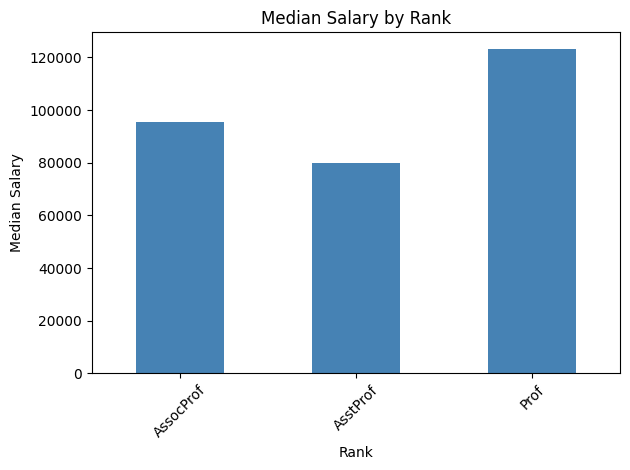

In [ ]:
median_salary_rank.plot(kind='bar', color='steelblue')
plt.title('Median Salary by Rank')
plt.xlabel('Rank')
plt.ylabel('Median Salary')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Bar chart : median salary by sex

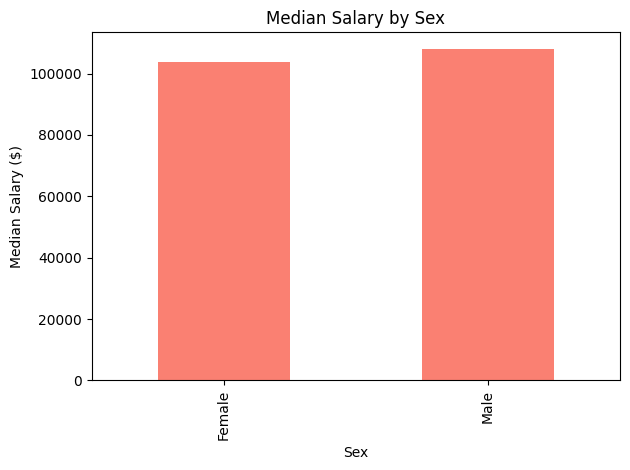

In [ ]:
median_salary_sex.plot(kind='bar', color='salmon')
plt.title('Median Salary by Sex')
plt.xlabel('Sex')
plt.ylabel('Median Salary ($)')
plt.tight_layout()
plt.show()

Boxplot: salary distribution by rank

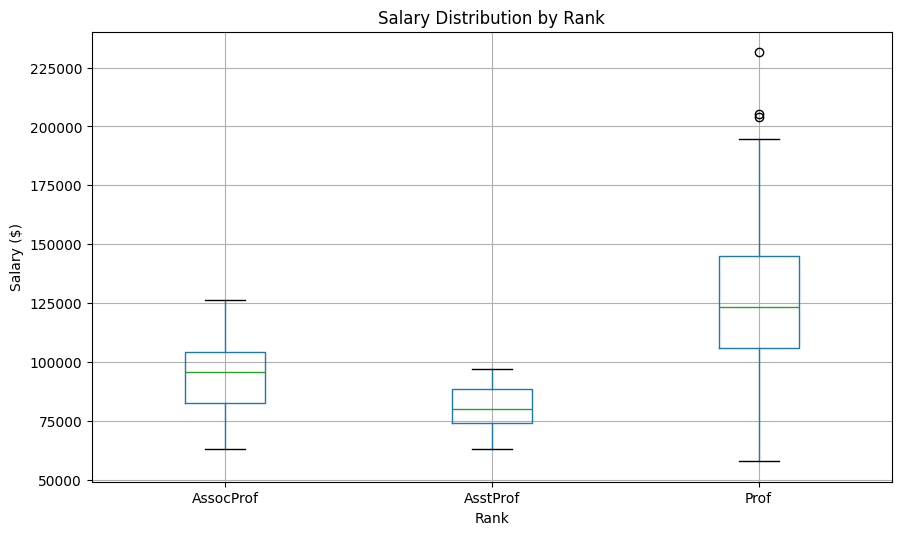

In [ ]:
df.boxplot(column='salary', by='rank', figsize=(10, 6))
plt.title('Salary Distribution by Rank')
plt.suptitle('') # removes the default subtitle
plt.xlabel('Rank')
plt.ylabel('Salary ($)')
plt.show()

# Conclusions : What did i discover?


* Salary increases steadily with rank, as expected.
* A gender pay gap exists overall (~3.97%) and persists at every rank level.
* The largest gap is at the Associate Professor level (5.30%).
* No missing data was found; all 397 records are complete.